# 02 — EDA (Exploratory Data Analysis)
## Construction Safety Helmet — YOLO26

Versi **langkah-demi-langkah** dari [`src/eda.py`](../src/eda.py): tiap sel menampilkan hasil antara (tabel) dan visualisasi **inline**. Logika analisis tetap memakai fungsi publik di `src/eda.py`.

## Setup

In [ ]:
# === Setup — jalankan sel ini lebih dulu ===
import os, sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / "src").is_dir() and (d / "dataset").exists():
            return d
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: D:\ML\test-code\construction-safety-helmet-yolo26


## 1. Import & konfigurasi dataset

In [ ]:
import eda
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import Image, display

DATA_YAML = "dataset/data.yaml"
data, class_names, nc, root = eda.load_dataset_config(DATA_YAML)
print("jumlah kelas:", nc, "->", class_names)
splits = eda.resolve_splits(root, data)
print("split terdeteksi:", list(splits.keys()))

jumlah kelas: 3 -> ['Helmet', 'No-Helmet', 'Person']
split terdeteksi: ['train', 'valid', 'test']


## 2. Analisis dataset (baca semua label)

In [ ]:
# Membaca seluruh label; img_sample membatasi pembacaan UKURAN gambar agar cepat
# (statistik ukuran jadi perkiraan; hitungan kelas/bbox tetap penuh).
# redirect_stderr meredam progress-bar tqdm agar output notebook bersih.
import os, contextlib
with open(os.devnull, "w") as _null, contextlib.redirect_stderr(_null):
    result = eda.analyze(DATA_YAML, img_sample=1500)
print("total bounding box:", result["total_bboxes"])

total bounding box: 58368


## 3. Ringkasan per split

In [ ]:
rows = []
for s in result["splits"]:
    d = result["per_split"][s]
    rows.append({"split": s, "images": d["n_images"], "labels": d["n_labels"],
                 "bboxes": d["n_bboxes"], "no_anno": d["n_images_no_anno"],
                 "bbox/img": round(d["avg_bboxes_per_image"], 2)})
pd.DataFrame(rows).set_index("split")

,images,labels,bboxes,no_anno,bbox/img
split,,,,,
train,15566,15566,41174,2,2.65
valid,1945,1945,12416,0,6.38
test,1945,1945,4778,0,2.46


## 4. Distribusi kelas

,class,count,percent
0,Helmet,27813,47.65
1,No-Helmet,4668,8.00
2,Person,25887,44.35


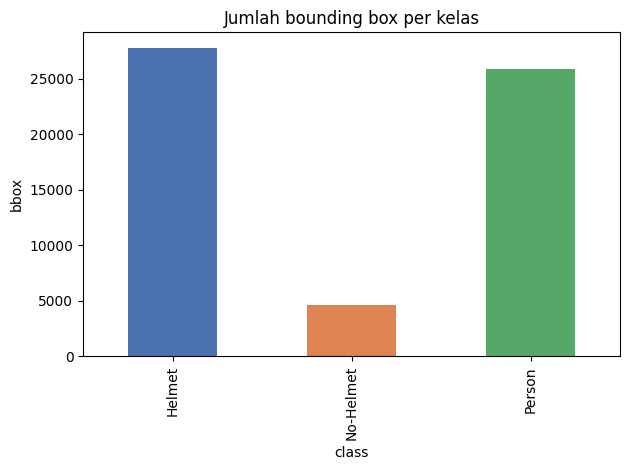

rasio imbalance (maks/min): 6.0x


In [ ]:
dist = pd.DataFrame({
    "class": [result["class_names"][c] for c in range(result["nc"])],
    "count": [result["class_counts_total"][c] for c in range(result["nc"])],
    "percent": [round(result["class_pct"][c], 2) for c in range(result["nc"])],
})
display(dist)
ax = dist.plot.bar(x="class", y="count", legend=False, color=["#4c72b0", "#dd8452", "#55a868"],
                   title="Jumlah bounding box per kelas")
ax.set_ylabel("bbox"); plt.tight_layout(); plt.show()
print(f"rasio imbalance (maks/min): {result['imbalance_ratio']:.1f}x")

## 5. Statistik ukuran bounding box

komposisi ukuran objek (area relatif): small=9.5%  medium=29.6%  large=60.9%


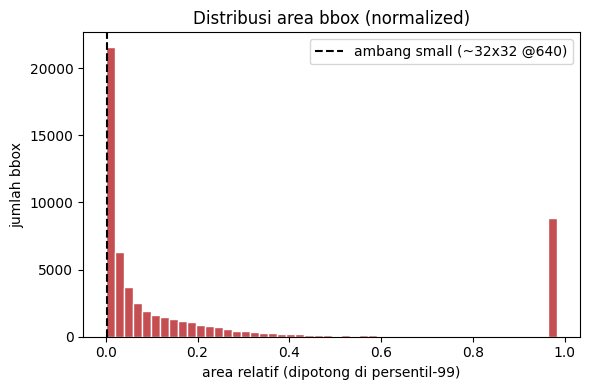

In [ ]:
print(f"komposisi ukuran objek (area relatif): "
      f"small={result['frac_small']*100:.1f}%  "
      f"medium={result['frac_medium']*100:.1f}%  "
      f"large={result['frac_large']*100:.1f}%")

area = result["bbox_area"]
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(np.clip(area, 0, np.percentile(area, 99)), bins=50, color="#c44e52", edgecolor="white")
ax.axvline(eda.SMALL_AREA_THR, color="black", ls="--", label="ambang small (~32x32 @640)")
ax.set_title("Distribusi area bbox (normalized)")
ax.set_xlabel("area relatif (dipotong di persentil-99)"); ax.set_ylabel("jumlah bbox")
ax.legend(); plt.tight_layout(); plt.show()

## 6. Tulis artefak & tampilkan semua figur

figur tersimpan: ['images_per_split.png', 'bboxes_per_class.png', 'bboxes_per_image_hist.png', 'bbox_wh_scatter.png', 'bbox_area_hist.png', 'split_proportion_pie.png']


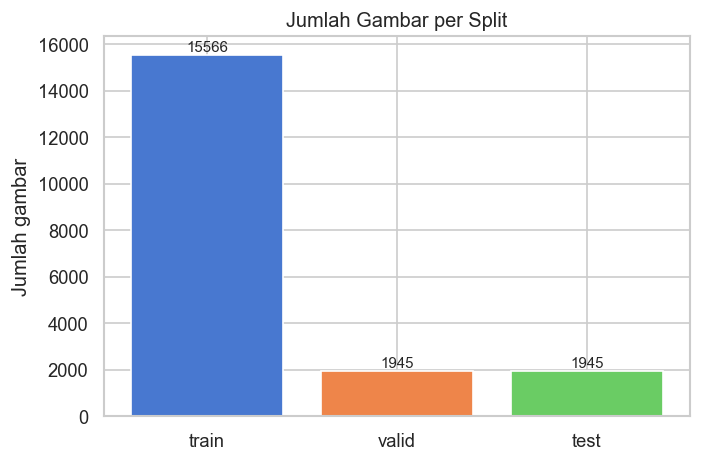

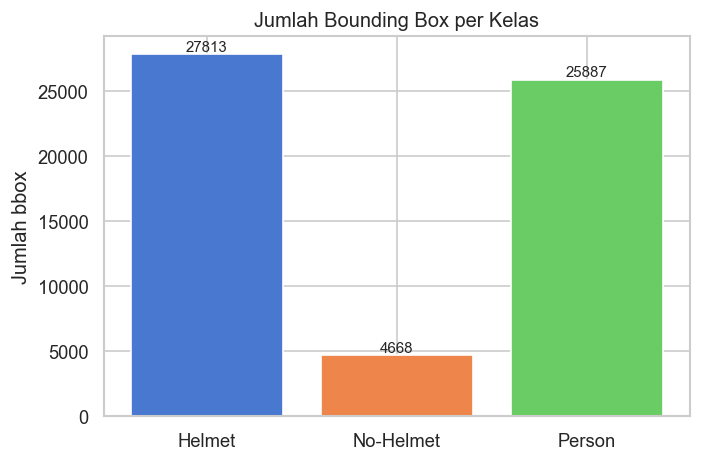

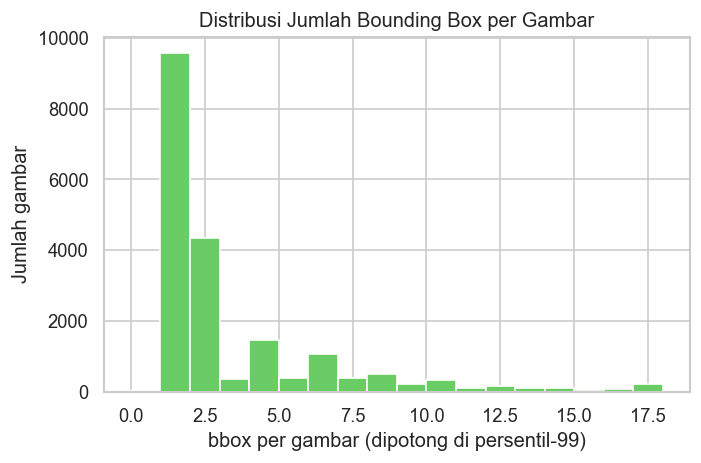

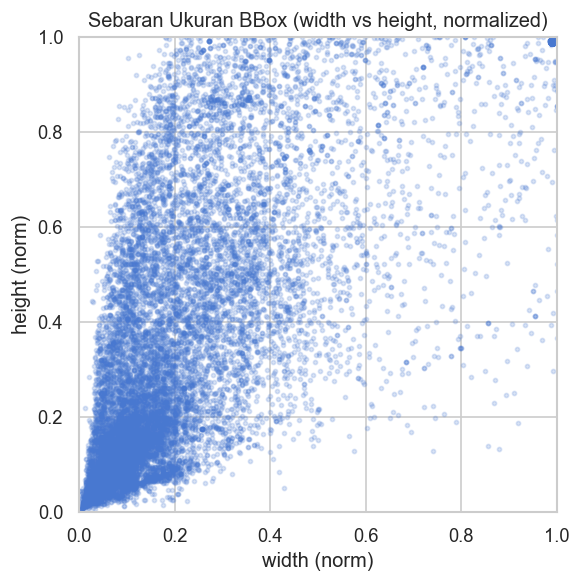

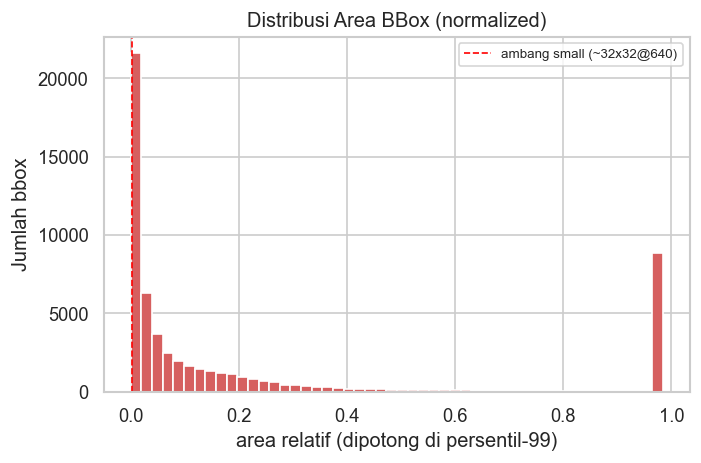

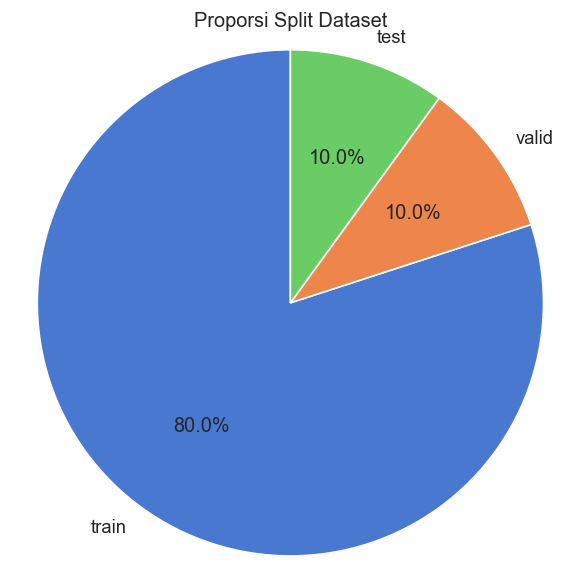

In [ ]:
# Tulis CSV + report + 6 figur PNG ke runs/eda/, lalu tampilkan semua figur inline.
out = Path("runs/eda"); out.mkdir(parents=True, exist_ok=True)
eda.write_outputs(result, out)
report = eda.build_report_text(result)
(out / "eda_report.txt").write_text(report, encoding="utf-8")

figs = eda.make_figures(result, out / "figures")
print("figur tersimpan:", [f.name for f in figs])
for f in figs:
    display(Image(filename=str(f)))

## 7. Laporan teks lengkap

In [ ]:
print(report)

LAPORAN EDA - DATASET YOLO (object detection)
data.yaml    : dataset\data.yaml
dataset root : D:\ML\test-code\construction-safety-helmet-yolo26\dataset
jumlah kelas : 3 -> ['Helmet', 'No-Helmet', 'Person']

RINGKASAN PER SPLIT
----------------------------------------------------------------
split      images   labels   bboxes  no_anno  bbox/img
train       15566    15566    41174        2      2.65
valid        1945     1945    12416        0      6.38
test         1945     1945     4778        0      2.46

DISTRIBUSI KELAS (total bbox & persentase)
----------------------------------------------------------------
id  class              count   percent
0   Helmet             27813    47.65%
1   No-Helmet           4668     8.00%
2   Person             25887    44.35%

STATISTIK UKURAN GAMBAR (pixel)
----------------------------------------------------------------
  width  : avg=496.0  min=80  max=5544
  height : avg=463.0  min=80  max=3360
  (catatan: dihitung dari sampel gambar)

STATI